Densité de l'air moyenne : 1.2699 kg/m³
Surface balayée A = 2827.4 m²

--- Résultat de la régression ---
η optimal  = 0.4000  ±  0.0001
Cp = η × 16/27 = 0.2370
RMSE = 12.8 kW  |  R² = 0.9987


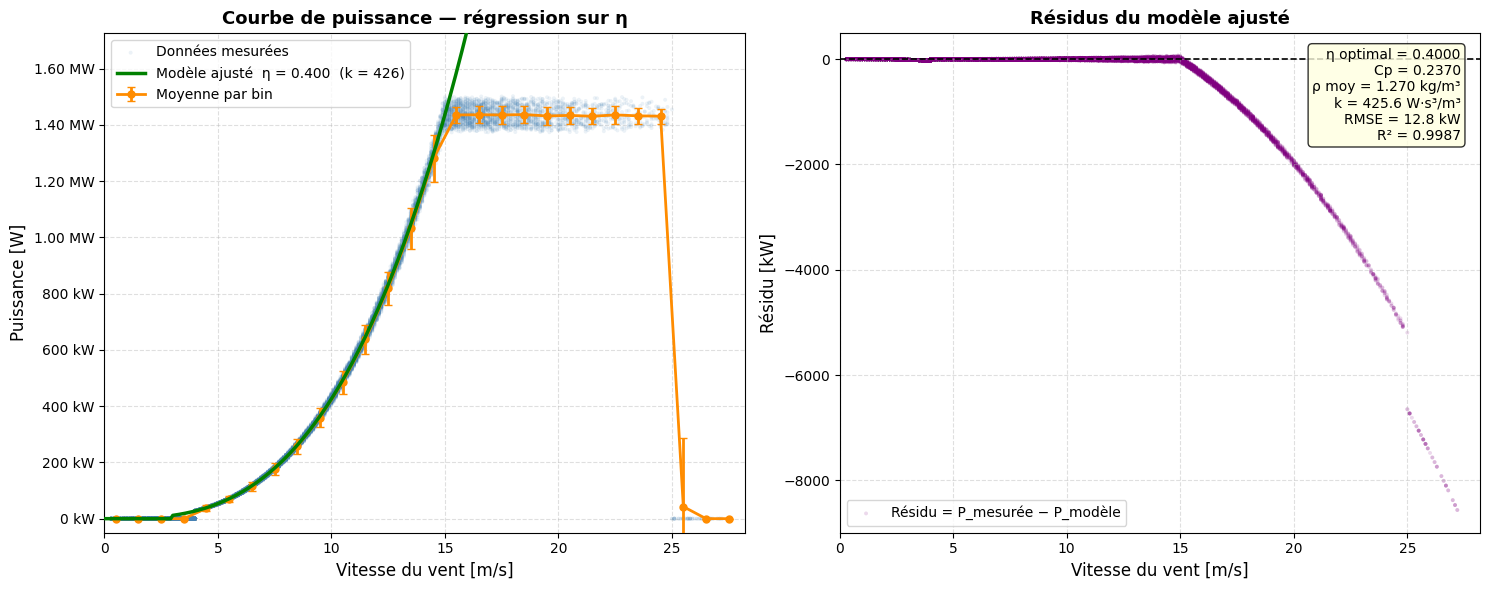

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit

# --- Chargement des données ---
df = pd.read_csv('donnees.txt', sep='\t', skipinitialspace=True)
df.columns = df.columns.str.strip()
df = df[df['Statut'] == 1].copy()

vitesse   = df['Vitess_Vent_[m/s]'].values
puissance = df['Pelec[w]'].values
patm      = df['Patm[Pa]'].values
temp      = df['Temp[degC]'].values + 273.15

# --- Paramètres fixes ---
D     = 60.0
R_air = 287.0
A     = np.pi * D**2 / 4

# --- Densité de l'air moyenne ---
rho_moy = np.mean(patm / (R_air * temp))
print(f"Densité de l'air moyenne : {rho_moy:.4f} kg/m³")
print(f"Surface balayée A = {A:.1f} m²")

# --- Régression pour trouver eta ---
mask = (vitesse >= 3) & (vitesse <= 15)

def modele(V, eta):
    Cp = eta * (16/27)
    k  = Cp * 0.5 * rho_moy * A
    return k * V**3

popt, pcov = curve_fit(modele, vitesse[mask], puissance[mask],
                       p0=[0.20], bounds=(0.0, 0.6))
eta_opt = popt[0]
eta_std  = np.sqrt(pcov[0][0])

k_opt = eta_opt * (16/27) * 0.5 * rho_moy * A

p_pred = k_opt * vitesse[mask]**3
rmse = np.sqrt(np.mean((p_pred - puissance[mask])**2))
r2   = 1 - np.sum((puissance[mask] - p_pred)**2) / np.sum((puissance[mask] - np.mean(puissance[mask]))**2)

print(f"\n--- Résultat de la régression ---")
print(f"η optimal  = {eta_opt:.4f}  ±  {eta_std:.4f}")
print(f"Cp = η × 16/27 = {eta_opt * 16/27:.4f}")
print(f"RMSE = {rmse/1000:.1f} kW  |  R² = {r2:.4f}")

# --- Courbe d'ajustement ---
v_fit   = np.linspace(0, vitesse.max() + 1, 300)
p_fit   = np.where(v_fit >= 3, k_opt * v_fit**3, 0)

# --- Moyenne par bins ---
bins = np.arange(0, vitesse.max() + 2, 1)
mean_p, bin_edges, _ = binned_statistic(vitesse, puissance, statistic='mean', bins=bins)
std_p,  _,         _ = binned_statistic(vitesse, puissance, statistic='std',  bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
valid = ~np.isnan(mean_p)

# --- Tracé ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Graphe gauche : courbe de puissance ----
ax = axes[0]
ax.scatter(vitesse, puissance, color='steelblue', alpha=0.1,
           edgecolors='none', s=8, label='Données mesurées', zorder=2)
ax.errorbar(bin_centers[valid], mean_p[valid], yerr=std_p[valid],
            fmt='o-', color='darkorange', linewidth=2, markersize=5,
            capsize=3, label='Moyenne par bin', zorder=4)
ax.plot(v_fit, p_fit, '-', color='green', linewidth=2.5,
        label=f'Modèle ajusté  η = {eta_opt:.3f}  (k = {k_opt:.0f})', zorder=5)

ax.set_xlabel('Vitesse du vent [m/s]', fontsize=12)
ax.set_ylabel('Puissance [W]', fontsize=12)
ax.set_title("Courbe de puissance — régression sur η", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(0, vitesse.max() + 1)
ax.set_ylim(-50000, puissance.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'{x/1e6:.2f} MW' if x >= 1e6 else f'{x/1e3:.0f} kW'))

# ---- Graphe droit : résidus ----
ax2 = axes[1]
p_pred_all = np.where(vitesse >= 2.5, k_opt * vitesse**3, 0)
residus = puissance - p_pred_all
ax2.scatter(vitesse, residus/1000, color='purple', alpha=0.15,
            edgecolors='none', s=8, label='Résidu = P_mesurée − P_modèle')
ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax2.set_xlabel('Vitesse du vent [m/s]', fontsize=12)
ax2.set_ylabel('Résidu [kW]', fontsize=12)
ax2.set_title("Résidus du modèle ajusté", fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_xlim(0, vitesse.max() + 1)

textstr = (f'η optimal = {eta_opt:.4f}\n'
           f'Cp = {eta_opt*16/27:.4f}\n'
           f'ρ moy = {rho_moy:.3f} kg/m³\n'
           f'k = {k_opt:.1f} W·s³/m³\n'
           f'RMSE = {rmse/1000:.1f} kW\n'
           f'R² = {r2:.4f}')
ax2.text(0.97, 0.97, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('courbe_puissance_eolienne.png', dpi=150, bbox_inches='tight')
plt.show()

Paramètres Weibull : k (forme) = 1.827, λ (échelle) = 9.871 m/s


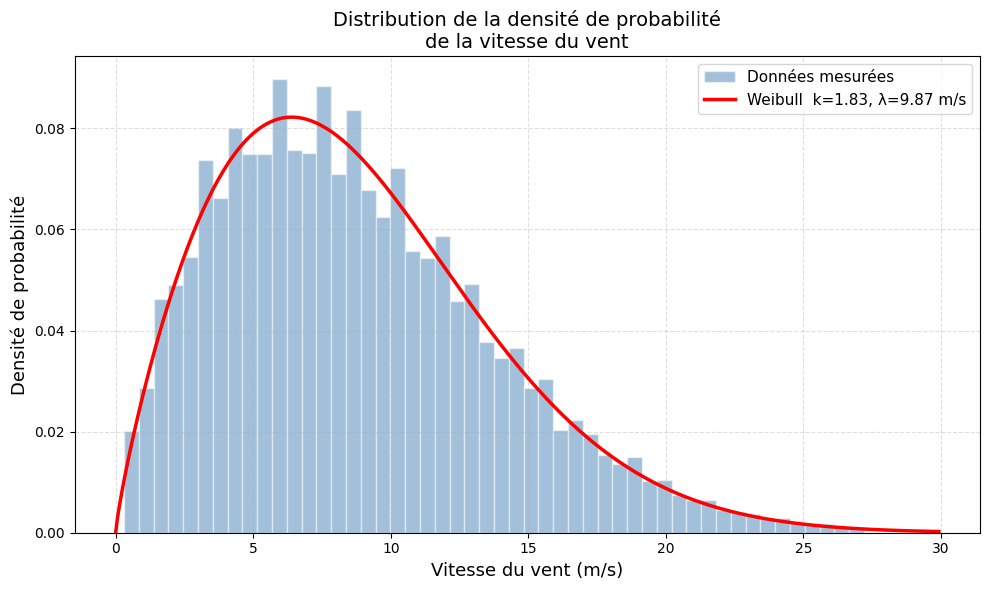

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma

# --- Chargement des données ---
df = pd.read_csv("donnees.txt", sep="\t", skipinitialspace=True)
df.columns = df.columns.str.strip()
vitesse = df["Vitess_Vent_[m/s]"].dropna()

# --- Ajustement Weibull ---
# scipy utilise la convention (c, loc, scale) où c = k (facteur de forme)
c, loc, scale = stats.weibull_min.fit(vitesse, floc=0)
k = c          # facteur de forme
lam = scale    # facteur d'échelle (lambda)

print(f"Paramètres Weibull : k (forme) = {k:.3f}, λ (échelle) = {lam:.3f} m/s")

# --- Ajustement Gaussienne (pour comparaison) ---
mu, sigma = stats.norm.fit(vitesse)

# --- Tracé ---
fig, ax = plt.subplots(figsize=(10, 6))

# Histogramme normalisé (densité)
ax.hist(vitesse, bins=50, density=True, alpha=0.5, color="steelblue",
        edgecolor="white", label="Données mesurées")

# Courbe Weibull
x = np.linspace(0, vitesse.max() * 1.1, 500)
pdf_weibull = stats.weibull_min.pdf(x, c, loc=0, scale=lam)
ax.plot(x, pdf_weibull, "r-", lw=2.5,
        label=f"Weibull  k={k:.2f}, λ={lam:.2f} m/s")



# Mise en forme
ax.set_xlabel("Vitesse du vent (m/s)", fontsize=13)
ax.set_ylabel("Densité de probabilité", fontsize=13)
ax.set_title("Distribution de la densité de probabilité\nde la vitesse du vent", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("distribution_vitesse_vent.png", dpi=150)
plt.show()